# Graph Databases: Modeling Relationships with Neo4j

Some of the most important questions we ask about data are fundamentally about **relationships**: Who knows whom? Which accounts share the same device? How many hops separate two people in a network? Which products are related through shared purchases?

Relational databases answer these questions with JOINs, but JOINs across unknown depths become painful fast. Graph databases are built from the ground up to answer relationship-centric questions efficiently.

This notebook covers:
- What graph databases model: nodes, relationships, properties
- When graphs beat relational databases
- NetworkX: in-memory graph exploration in Python
- Neo4j and the Cypher query language
- Knowledge graphs for RAG
- Graph ML concepts: node2vec, graph embeddings
- Real-world use cases and database comparisons

## 1. The Graph Data Model

A graph database stores data as three building blocks:

| Element | Description | Example |
|---------|-------------|----------|
| **Node** | An entity (labeled) | `(:Person {name: "Alice"})` |
| **Relationship** | A directed connection between two nodes (also labeled) | `-[:FRIENDS_WITH {since: 2020}]->` |
| **Property** | A key-value pair on a node or relationship | `{name: "Alice", age: 32}` |

This is called the **Property Graph Model** -- the standard behind Neo4j, TigerGraph, and Amazon Neptune.

### Why not just use SQL JOINs?

Consider finding friends-of-friends-of-friends in a social network:

**SQL approach** (3 hops):
```sql
SELECT DISTINCT f3.name
FROM friendships f1
JOIN friendships f2 ON f1.friend_id = f2.user_id
JOIN friendships f3 ON f2.friend_id = f3.user_id
WHERE f1.user_id = 42;
```

**Cypher approach** (variable depth, 1 to 3 hops):
```cypher
MATCH (a:Person {name: 'Alice'})-[:FRIENDS_WITH*1..3]->(b:Person)
RETURN DISTINCT b.name
```

The SQL query must be rewritten for every different depth. The Cypher query handles variable depth natively. At 10+ hops, the SQL version becomes impractical; the graph version stays clean.

## 2. When to Choose a Graph Database

Choose a graph database when:

1. **Relationships are the primary query target** -- not just metadata, but the core of what you query
2. **Variable traversal depth** -- you need to find paths of unknown length (social networks, org charts)
3. **Many-to-many at scale** -- when a junction table in SQL becomes a performance bottleneck
4. **Pattern matching** -- find fraud rings, product relationships, supply chain bottlenecks

Stick with relational when:
- Data is primarily tabular with simple foreign key relationships
- You need strong ACID transactions across many entity types
- Your team's SQL expertise is high and relationship depth is bounded

| Use Case | Graph DB? | Why |
|----------|-----------|-----|
| Social network (friends, followers) | Yes | Variable-depth traversal |
| E-commerce orders | No | Simple FK relationships, strong transactions |
| Fraud ring detection | Yes | Pattern matching across shared entities |
| Product knowledge graph | Yes | Complex entity relationships |
| User authentication | No | Simple lookup |
| Supply chain (multi-tier) | Yes | Path finding, bottleneck detection |

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random
from collections import defaultdict

# Reproducible results
random.seed(42)

print(f"NetworkX version: {nx.__version__}")
print("NetworkX is a Python library for in-memory graph computation.")
print("It lets us prototype graph algorithms before connecting to Neo4j.")

NetworkX version: 3.6.1
NetworkX is a Python library for in-memory graph computation.
It lets us prototype graph algorithms before connecting to Neo4j.


## 3. Building a Social Network Graph with NetworkX

We will model 10 people with three types of relationships:
- **FRIENDS_WITH**: personal friendship
- **COLLEAGUE**: work relationship
- **FAMILY**: family relationship

This mirrors exactly what you would store in Neo4j as labeled relationships.

In [2]:
# Build a social network
G = nx.Graph()

# Add nodes (people) with properties
people = [
    {"name": "Alice",   "age": 32, "department": "Engineering"},
    {"name": "Bob",     "age": 29, "department": "Engineering"},
    {"name": "Carol",   "age": 41, "department": "Marketing"},
    {"name": "Dave",    "age": 35, "department": "Marketing"},
    {"name": "Eve",     "age": 28, "department": "Engineering"},
    {"name": "Frank",   "age": 45, "department": "HR"},
    {"name": "Grace",   "age": 31, "department": "HR"},
    {"name": "Henry",   "age": 38, "department": "Finance"},
    {"name": "Iris",    "age": 26, "department": "Finance"},
    {"name": "Jake",    "age": 33, "department": "Engineering"},
]

for person in people:
    G.add_node(person["name"], age=person["age"], department=person["department"])

# Add edges (relationships) with a 'type' property
edges = [
    ("Alice", "Bob",   {"type": "FRIENDS_WITH", "since": 2018}),
    ("Alice", "Carol", {"type": "COLLEAGUE",    "since": 2020}),
    ("Alice", "Frank", {"type": "FAMILY",       "since": 1990}),
    ("Bob",   "Eve",   {"type": "FRIENDS_WITH", "since": 2019}),
    ("Bob",   "Jake",  {"type": "COLLEAGUE",    "since": 2021}),
    ("Carol", "Dave",  {"type": "COLLEAGUE",    "since": 2017}),
    ("Carol", "Grace", {"type": "FRIENDS_WITH", "since": 2022}),
    ("Dave",  "Henry", {"type": "FRIENDS_WITH", "since": 2015}),
    ("Eve",   "Jake",  {"type": "FRIENDS_WITH", "since": 2020}),
    ("Frank", "Grace", {"type": "COLLEAGUE",    "since": 2019}),
    ("Grace", "Henry", {"type": "FRIENDS_WITH", "since": 2021}),
    ("Henry", "Iris",  {"type": "COLLEAGUE",    "since": 2018}),
    ("Iris",  "Jake",  {"type": "FRIENDS_WITH", "since": 2023}),
    ("Alice", "Eve",   {"type": "COLLEAGUE",    "since": 2020}),
]

for u, v, attrs in edges:
    G.add_edge(u, v, **attrs)

print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
print(f"\nNode attributes for Alice: {G.nodes['Alice']}")
print(f"Edge attributes for Alice-Bob: {G.edges['Alice', 'Bob']}")

Graph has 10 nodes and 14 edges

Node attributes for Alice: {'age': 32, 'department': 'Engineering'}
Edge attributes for Alice-Bob: {'type': 'FRIENDS_WITH', 'since': 2018}


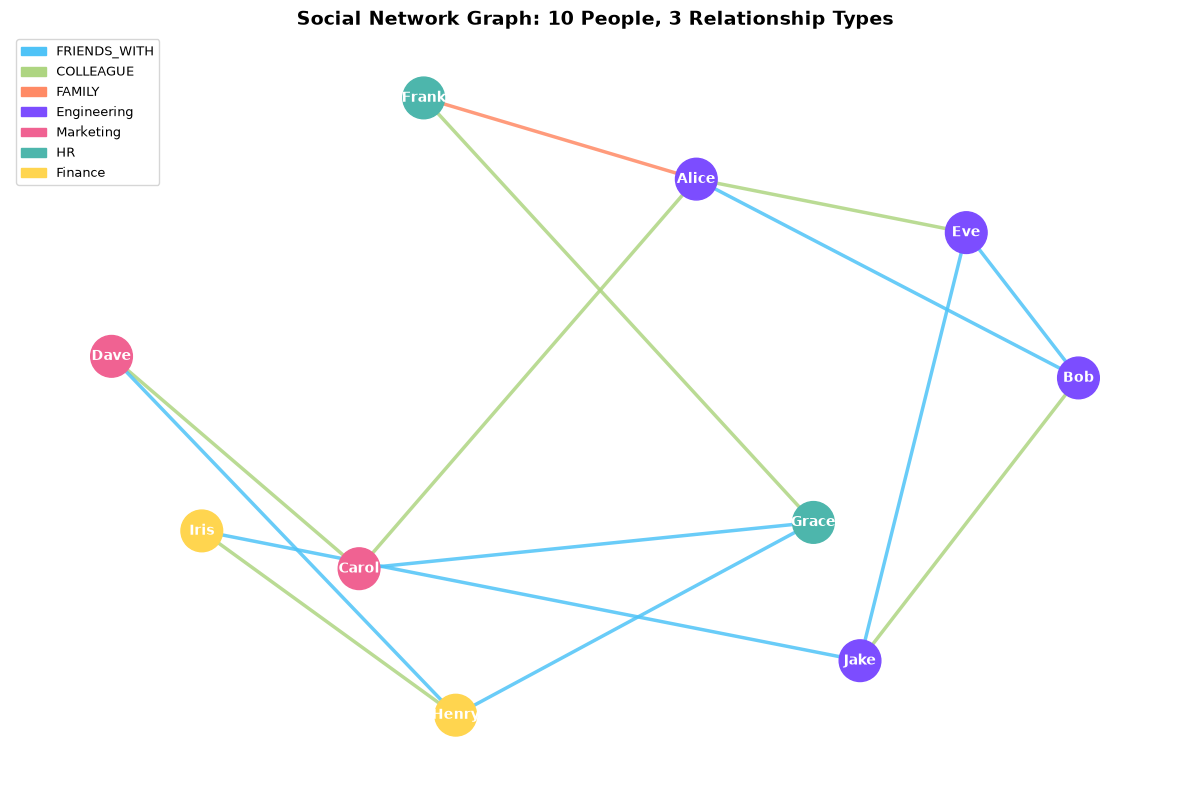

In Neo4j, each node would be stored with label :Person and properties.
Each edge would be stored as a directed relationship with its own label.


In [3]:
# Visualize the social network
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
pos = nx.spring_layout(G, seed=42, k=2.0)

# Color edges by relationship type
edge_colors = []
for u, v, data in G.edges(data=True):
    rel_type = data.get("type", "UNKNOWN")
    if rel_type == "FRIENDS_WITH":
        edge_colors.append("#4fc3f7")
    elif rel_type == "COLLEAGUE":
        edge_colors.append("#aed581")
    else:
        edge_colors.append("#ff8a65")

# Color nodes by department
dept_colors = {"Engineering": "#7c4dff", "Marketing": "#f06292",
               "HR": "#4db6ac", "Finance": "#ffd54f"}
node_colors = [dept_colors[G.nodes[n]["department"]] for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=900, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold", font_color="white", ax=ax)
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=2.5, alpha=0.85, ax=ax)

# Legend for edge types
legends = [
    mpatches.Patch(color="#4fc3f7", label="FRIENDS_WITH"),
    mpatches.Patch(color="#aed581", label="COLLEAGUE"),
    mpatches.Patch(color="#ff8a65", label="FAMILY"),
]
dept_patches = [mpatches.Patch(color=c, label=d) for d, c in dept_colors.items()]
ax.legend(handles=legends + dept_patches, loc="upper left", fontsize=9)
ax.set_title("Social Network Graph: 10 People, 3 Relationship Types", fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()
print("In Neo4j, each node would be stored with label :Person and properties.")
print("Each edge would be stored as a directed relationship with its own label.")

## 4. Graph Traversal: Shortest Path

One of the core graph queries is **shortest path**: what is the minimum number of hops to get from node A to node B? This underlies LinkedIn's 'degrees of separation' feature and fraud detection (path between two accounts).

In [4]:
# Shortest path between two people
source, target = "Alice", "Iris"
path = nx.shortest_path(G, source=source, target=target)
path_length = nx.shortest_path_length(G, source=source, target=target)

print(f"Shortest path from {source} to {target}:")
print(" -> ".join(path))
print(f"Path length: {path_length} hops")

print("\nRelationship types along the path:")
for i in range(len(path) - 1):
    u, v = path[i], path[i+1]
    rel = G.edges[u, v].get("type", "UNKNOWN")
    print(f"  ({u})-[:{rel}]->({v})")

print("\nEquivalent Cypher query in Neo4j:")
print(f"""
MATCH p = shortestPath(
    (a:Person {{name: '{source}'}})-[*]-(b:Person {{name: '{target}'}})
)
RETURN p, length(p) AS hops
""")

# All shortest paths
all_paths = list(nx.all_shortest_paths(G, source=source, target=target))
print(f"Number of shortest paths (same length): {len(all_paths)}")

Shortest path from Alice to Iris:
Alice -> Bob -> Jake -> Iris
Path length: 3 hops

Relationship types along the path:
  (Alice)-[:FRIENDS_WITH]->(Bob)
  (Bob)-[:COLLEAGUE]->(Jake)
  (Jake)-[:FRIENDS_WITH]->(Iris)

Equivalent Cypher query in Neo4j:

MATCH p = shortestPath(
    (a:Person {name: 'Alice'})-[*]-(b:Person {name: 'Iris'})
)
RETURN p, length(p) AS hops

Number of shortest paths (same length): 2


## 5. Community Detection

Community detection finds clusters of nodes that are more densely connected to each other than to the rest of the graph. This is used for:
- Identifying friend groups in social networks
- Finding fraud rings
- Market segmentation in product graphs

Found 2 communities:

Community 1: ['Carol', 'Dave', 'Frank', 'Grace', 'Henry', 'Iris']
  Departments: ['Marketing', 'Marketing', 'HR', 'HR', 'Finance', 'Finance']

Community 2: ['Alice', 'Bob', 'Eve', 'Jake']
  Departments: ['Engineering', 'Engineering', 'Engineering', 'Engineering']



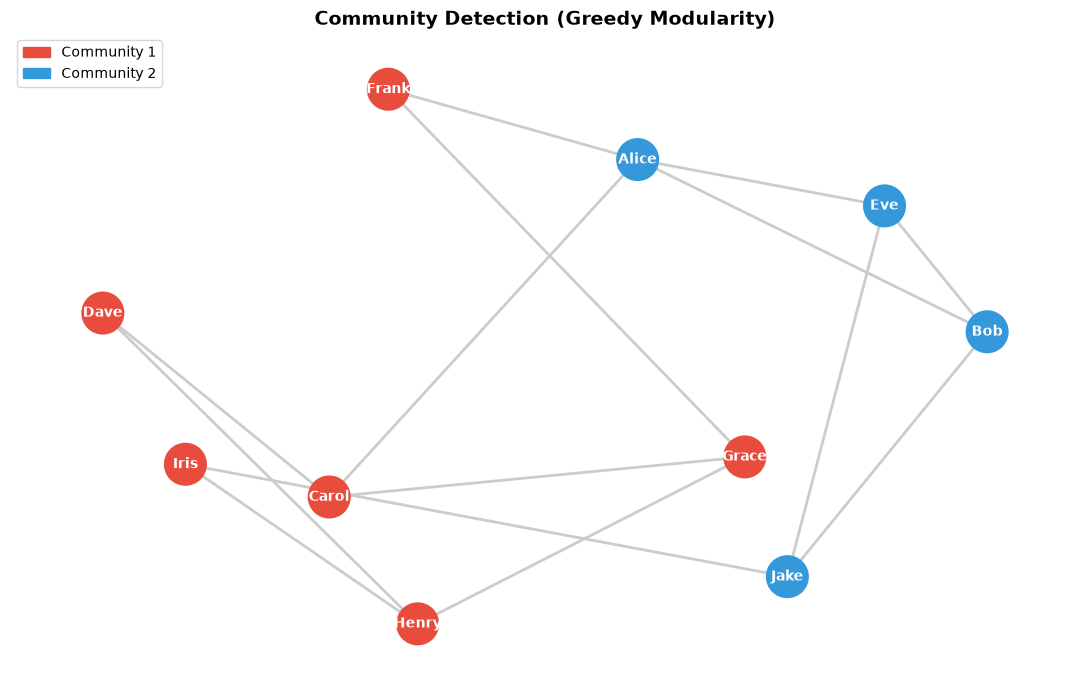

In [5]:
from networkx.algorithms import community

# Greedy modularity maximization
communities = list(community.greedy_modularity_communities(G))

print(f"Found {len(communities)} communities:\n")
for i, comm in enumerate(communities):
    members = sorted(comm)
    depts = [G.nodes[m]["department"] for m in members]
    print(f"Community {i+1}: {members}")
    print(f"  Departments: {depts}")
    print()

# Visualize communities
fig, ax = plt.subplots(figsize=(11, 7))
community_palette = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]
node_comm_colors = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_comm_colors[node] = community_palette[i % len(community_palette)]

nc = [node_comm_colors[n] for n in G.nodes()]
nx.draw_networkx(G, pos, node_color=nc, node_size=900,
                 font_size=10, font_weight="bold", font_color="white",
                 edge_color="#cccccc", width=2, ax=ax)
comm_patches = [mpatches.Patch(color=community_palette[i], label=f"Community {i+1}")
                for i in range(len(communities))]
ax.legend(handles=comm_patches, loc="upper left")
ax.set_title("Community Detection (Greedy Modularity)", fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

## 6. Centrality Measures

Centrality measures identify the most **influential** nodes in a graph. Different measures capture different notions of importance:

| Measure | Question | Use Case |
|---------|----------|----------|
| **Degree centrality** | How many direct connections? | Hubs, influencers |
| **Betweenness centrality** | How often does a node lie on shortest paths? | Bridges, bottlenecks |
| **PageRank** | How important are your neighbors? | Web ranking, influence |
| **Closeness centrality** | How quickly can a node reach all others? | Information spread |

In [6]:
# Compute centrality measures
degree_cent = nx.degree_centrality(G)
betweenness_cent = nx.betweenness_centrality(G)
pagerank = nx.pagerank(G, alpha=0.85)
closeness_cent = nx.closeness_centrality(G)

print("Centrality Comparison (top 5 by PageRank):\n")
print(f"{'Person':<10} {'Degree':>8} {'Betweenness':>12} {'PageRank':>10} {'Closeness':>10}")
print("-" * 52)
sorted_by_pr = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)
for name, pr in sorted_by_pr:
    print(f"{name:<10} {degree_cent[name]:>8.3f} {betweenness_cent[name]:>12.3f} "
          f"{pr:>10.4f} {closeness_cent[name]:>10.3f}")

print("\nInsights:")
top_degree = max(degree_cent, key=degree_cent.get)
top_between = max(betweenness_cent, key=betweenness_cent.get)
top_pr = max(pagerank, key=pagerank.get)
print(f"  Most connections (Degree):  {top_degree}")
print(f"  Bridge node (Betweenness):  {top_between}")
print(f"  Most influential (PageRank): {top_pr}")

Centrality Comparison (top 5 by PageRank):

Person       Degree  Betweenness   PageRank  Closeness
----------------------------------------------------
Alice         0.444        0.301     0.1352      0.562
Henry         0.333        0.190     0.1107      0.500
Grace         0.333        0.134     0.1083      0.500
Carol         0.333        0.176     0.1070      0.529
Jake          0.333        0.139     0.1057      0.474
Bob           0.333        0.056     0.1028      0.500
Eve           0.333        0.056     0.1028      0.500
Dave          0.222        0.037     0.0767      0.450
Iris          0.222        0.139     0.0763      0.474
Frank         0.222        0.051     0.0744      0.474

Insights:
  Most connections (Degree):  Alice
  Bridge node (Betweenness):  Alice
  Most influential (PageRank): Alice


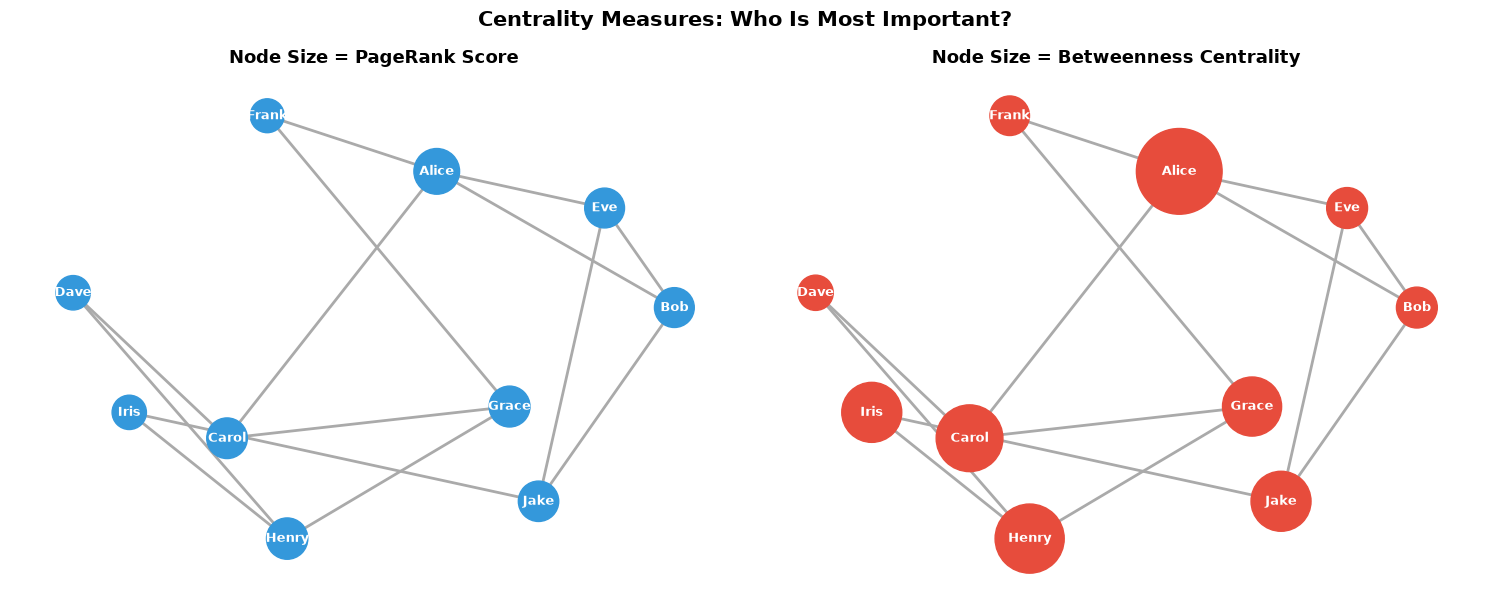

In [7]:
# Visualize centrality (node size = PageRank)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: PageRank sized
pr_sizes = [pagerank[n] * 8000 for n in G.nodes()]
nx.draw_networkx(G, pos, node_size=pr_sizes, node_color="#3498db",
                 font_size=9, font_weight="bold", font_color="white",
                 edge_color="#aaaaaa", width=2, ax=axes[0])
axes[0].set_title("Node Size = PageRank Score", fontsize=13, fontweight="bold")
axes[0].axis("off")

# Right: Betweenness sized
bt_sizes = [betweenness_cent[n] * 12000 + 200 for n in G.nodes()]
nx.draw_networkx(G, pos, node_size=bt_sizes, node_color="#e74c3c",
                 font_size=9, font_weight="bold", font_color="white",
                 edge_color="#aaaaaa", width=2, ax=axes[1])
axes[1].set_title("Node Size = Betweenness Centrality", fontsize=13, fontweight="bold")
axes[1].axis("off")

plt.suptitle("Centrality Measures: Who Is Most Important?", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Neo4j and the Cypher Query Language

Neo4j is the most widely used graph database. It stores data natively as a property graph and uses **Cypher**, a declarative query language with ASCII art pattern matching.

### Core Cypher Syntax

Nodes are wrapped in `()`, relationships in `[]`, and the direction is shown with `->` or `<-`:

```cypher
-- A node
(n:Person {name: "Alice"})

-- A relationship
(a)-[:FRIENDS_WITH {since: 2020}]->(b)

-- A pattern (Alice's friends)
MATCH (a:Person {name: "Alice"})-[:FRIENDS_WITH]->(b:Person)
RETURN b.name
```

### The Six Core Clauses

| Clause | Purpose |
|--------|----------|
| `MATCH` | Find patterns in the graph |
| `WHERE` | Filter matched patterns |
| `RETURN` | Select what to return |
| `CREATE` | Create nodes/relationships |
| `MERGE` | Create if not exists (upsert) |
| `SET` | Update properties |

In [8]:
# Neo4j connection pattern
# NOTE: No Neo4j server is running. This shows the connection and query pattern.

neo4j_connection_example = '''
from neo4j import GraphDatabase

# Connect to Neo4j (local or Aura cloud)
URI  = "neo4j+s://abc123.databases.neo4j.io"   # Neo4j Aura free tier
AUTH = ("neo4j", "your-password")

driver = GraphDatabase.driver(URI, auth=AUTH)

def find_friends(tx, person_name):
    result = tx.run(
        "MATCH (a:Person {name: $name})-[:FRIENDS_WITH]->(b:Person) "
        "RETURN b.name AS friend, b.age AS age",
        name=person_name
    )
    return [record.data() for record in result]

with driver.session(database="neo4j") as session:
    friends = session.execute_read(find_friends, "Alice")
    for f in friends:
        print(f["friend"], f["age"])

driver.close()
'''
print("Neo4j Connection Pattern:")
print(neo4j_connection_example)

Neo4j Connection Pattern:

from neo4j import GraphDatabase

# Connect to Neo4j (local or Aura cloud)
URI  = "neo4j+s://abc123.databases.neo4j.io"   # Neo4j Aura free tier
AUTH = ("neo4j", "your-password")

driver = GraphDatabase.driver(URI, auth=AUTH)

def find_friends(tx, person_name):
    result = tx.run(
        "MATCH (a:Person {name: $name})-[:FRIENDS_WITH]->(b:Person) "
        "RETURN b.name AS friend, b.age AS age",
        name=person_name
    )
    return [record.data() for record in result]

with driver.session(database="neo4j") as session:
    friends = session.execute_read(find_friends, "Alice")
    for f in friends:
        print(f["friend"], f["age"])

driver.close()



In [9]:
# Cypher query examples -- explained with context
cypher_examples = [
    (
        "Create a Person node",
        "CREATE (p:Person {name: 'Alice', age: 32, department: 'Engineering'}) RETURN p"
    ),
    (
        "Create a relationship",
        "MATCH (a:Person {name: 'Alice'}), (b:Person {name: 'Bob'})\n"
        "CREATE (a)-[:FRIENDS_WITH {since: 2018}]->(b)"
    ),
    (
        "MERGE (upsert -- create if not exists)",
        "MERGE (p:Person {name: 'Alice'})\n"
        "ON CREATE SET p.age = 32\n"
        "ON MATCH SET p.last_seen = datetime()"
    ),
    (
        "Find all friends",
        "MATCH (a:Person {name: 'Alice'})-[:FRIENDS_WITH]->(b:Person)\n"
        "RETURN b.name, b.age"
    ),
    (
        "Friends-of-friends (2 hops)",
        "MATCH (a:Person {name: 'Alice'})-[:FRIENDS_WITH*2]->(b:Person)\n"
        "WHERE a <> b\nRETURN DISTINCT b.name"
    ),
    (
        "Variable depth (1 to 3 hops)",
        "MATCH (a:Person {name: 'Alice'})-[:FRIENDS_WITH*1..3]->(b:Person)\n"
        "RETURN DISTINCT b.name, b.department"
    ),
    (
        "Aggregation by department",
        "MATCH (n:Person)\n"
        "RETURN n.department AS dept, count(*) AS headcount\n"
        "ORDER BY headcount DESC"
    ),
    (
        "Shortest path",
        "MATCH p = shortestPath(\n"
        "  (a:Person {name: 'Alice'})-[*]-(b:Person {name: 'Iris'})\n"
        ")\nRETURN p, length(p) AS hops"
    ),
]

for label, query in cypher_examples:
    print(f"--- {label} ---")
    print(query)
    print()

--- Create a Person node ---
CREATE (p:Person {name: 'Alice', age: 32, department: 'Engineering'}) RETURN p

--- Create a relationship ---
MATCH (a:Person {name: 'Alice'}), (b:Person {name: 'Bob'})
CREATE (a)-[:FRIENDS_WITH {since: 2018}]->(b)

--- MERGE (upsert -- create if not exists) ---
MERGE (p:Person {name: 'Alice'})
ON CREATE SET p.age = 32
ON MATCH SET p.last_seen = datetime()

--- Find all friends ---
MATCH (a:Person {name: 'Alice'})-[:FRIENDS_WITH]->(b:Person)
RETURN b.name, b.age

--- Friends-of-friends (2 hops) ---
MATCH (a:Person {name: 'Alice'})-[:FRIENDS_WITH*2]->(b:Person)
WHERE a <> b
RETURN DISTINCT b.name

--- Variable depth (1 to 3 hops) ---
MATCH (a:Person {name: 'Alice'})-[:FRIENDS_WITH*1..3]->(b:Person)
RETURN DISTINCT b.name, b.department

--- Aggregation by department ---
MATCH (n:Person)
RETURN n.department AS dept, count(*) AS headcount
ORDER BY headcount DESC

--- Shortest path ---
MATCH p = shortestPath(
  (a:Person {name: 'Alice'})-[*]-(b:Person {name: 'Ir

## 8. Simulating Cypher-Style Queries with NetworkX

Since we cannot run Neo4j here, we simulate common Cypher query patterns using NetworkX. The logic is identical; only the syntax differs.

In [10]:
# Simulate: MATCH (a:Person {name: 'Alice'})-[:FRIENDS_WITH]->(b:Person) RETURN b
def find_friends(graph, person, rel_type="FRIENDS_WITH"):
    friends = []
    for neighbor in graph.neighbors(person):
        edge = graph.edges[person, neighbor]
        if edge.get("type") == rel_type:
            friends.append({"name": neighbor, **graph.nodes[neighbor]})
    return friends

print("Alice's friends (FRIENDS_WITH):")
for f in find_friends(G, "Alice"):
    print(f"  {f}")

# Simulate: friends-of-friends
def friends_of_friends(graph, person, rel_type="FRIENDS_WITH"):
    direct = {n for n in graph.neighbors(person)
              if graph.edges[person, n].get("type") == rel_type}
    fof = set()
    for friend in direct:
        for n in graph.neighbors(friend):
            if graph.edges[friend, n].get("type") == rel_type and n != person:
                fof.add(n)
    return fof - direct

print("\nAlice's friends-of-friends (FRIENDS_WITH):")
print(friends_of_friends(G, "Alice"))

# Simulate: aggregation by department
print("\nHeadcount by department:")
dept_count = defaultdict(int)
for n in G.nodes():
    dept_count[G.nodes[n]["department"]] += 1
for dept, count in sorted(dept_count.items(), key=lambda x: -x[1]):
    print(f"  {dept}: {count}")

Alice's friends (FRIENDS_WITH):
  {'name': 'Bob', 'age': 29, 'department': 'Engineering'}

Alice's friends-of-friends (FRIENDS_WITH):
{'Eve'}

Headcount by department:
  Engineering: 4
  Marketing: 2
  HR: 2
  Finance: 2


## 9. Knowledge Graphs for RAG

A **knowledge graph** stores entities and their relationships as structured facts. When used in RAG (Retrieval-Augmented Generation) systems, a knowledge graph enhances retrieval by:

1. **Traversing relationships**: instead of purely semantic similarity search, follow explicit relationships ("find all papers by Alice that cite Bob's work")
2. **Entity disambiguation**: distinguish "Apple (company)" from "apple (fruit)" via graph context
3. **Multi-hop reasoning**: answer questions that require chaining facts ("Who is the manager of the team that uses Python at company X?")
4. **Hybrid retrieval**: combine vector similarity with graph traversal for richer context

### Knowledge Graph RAG Architecture

```
User Query
     |
     v
Entity Extraction  ---> Knowledge Graph (Neo4j)
     |                        |
     v                        v
Vector Search         Graph Traversal
(Semantic)         (Structured facts)
     |                        |
     +----------+-------------+
                |
                v
         Combined Context
                |
                v
           LLM Response
```

In [11]:
# Build a simple knowledge graph for a product domain
KG = nx.DiGraph()  # Directed graph for knowledge graphs

# Entities with types
entities = [
    ("Python",       {"type": "Technology", "category": "language"}),
    ("PyTorch",      {"type": "Technology", "category": "framework"}),
    ("LLM",          {"type": "Concept",    "category": "AI"}),
    ("Transformer",  {"type": "Concept",    "category": "AI"}),
    ("OpenAI",       {"type": "Organization"}),
    ("Anthropic",    {"type": "Organization"}),
    ("GPT-4",        {"type": "Product",    "category": "LLM"}),
    ("Claude",       {"type": "Product",    "category": "LLM"}),
    ("RAG",          {"type": "Concept",    "category": "AI"}),
    ("Neo4j",        {"type": "Technology", "category": "database"}),
]

for name, attrs in entities:
    KG.add_node(name, **attrs)

# Relationships
relations = [
    ("PyTorch",     "Python",      "IMPLEMENTED_IN"),
    ("LLM",         "Transformer", "BASED_ON"),
    ("GPT-4",       "LLM",         "IS_A"),
    ("Claude",      "LLM",         "IS_A"),
    ("GPT-4",       "OpenAI",      "CREATED_BY"),
    ("Claude",      "Anthropic",   "CREATED_BY"),
    ("OpenAI",      "PyTorch",     "USES"),
    ("RAG",         "LLM",         "USES"),
    ("RAG",         "Neo4j",       "CAN_USE"),
    ("Neo4j",       "Python",      "HAS_DRIVER_FOR"),
]

for src, tgt, rel in relations:
    KG.add_edge(src, tgt, relation=rel)

# Simulate a graph-augmented RAG query
print("Query: 'What LLMs are available and who made them?'")
print()
llms = [n for n in KG.nodes() if any(
    KG.edges[n, nb].get("relation") == "IS_A" and nb == "LLM"
    for nb in KG.successors(n)
)]

for llm in llms:
    creators = [nb for nb in KG.successors(llm)
                if KG.edges[llm, nb].get("relation") == "CREATED_BY"]
    print(f"  {llm} -> created by {creators}")

print()
print("Equivalent Cypher:")
print("""
MATCH (llm:Product)-[:IS_A]->(:Concept {name: 'LLM'})
MATCH (llm)-[:CREATED_BY]->(org:Organization)
RETURN llm.name, org.name
""")

Query: 'What LLMs are available and who made them?'

  GPT-4 -> created by ['OpenAI']
  Claude -> created by ['Anthropic']

Equivalent Cypher:

MATCH (llm:Product)-[:IS_A]->(:Concept {name: 'LLM'})
MATCH (llm)-[:CREATED_BY]->(org:Organization)
RETURN llm.name, org.name



## 10. Graph ML: Node Embeddings and node2vec

Graph ML extends machine learning to graph-structured data. **Node embeddings** map each node to a vector in a low-dimensional space such that structurally similar nodes (same community, similar roles) are close in vector space.

**node2vec** generates node embeddings by:
1. Performing biased random walks from each node (controlling depth-first vs breadth-first)
2. Feeding the walk sequences to Word2Vec (treating nodes like words)
3. Producing a vector for each node

These vectors can then be used for:
- **Link prediction**: will Alice and Henry become connected?
- **Node classification**: is this account fraudulent?
- **Clustering**: similar nodes cluster together

Neo4j Graph Data Science (GDS) library has built-in implementations of node2vec, FastRP, and GraphSAGE.

In [12]:
# Simulate node2vec-style random walks on our graph
def random_walk(graph, start_node, walk_length=5, seed=None):
    """Simulate a random walk from start_node."""
    if seed:
        random.seed(seed)
    walk = [start_node]
    current = start_node
    for _ in range(walk_length - 1):
        neighbors = list(graph.neighbors(current))
        if not neighbors:
            break
        current = random.choice(neighbors)
        walk.append(current)
    return walk

print("Simulated random walks (as used by node2vec):")
for start in ["Alice", "Henry", "Frank"]:
    walk = random_walk(G, start, walk_length=6, seed=42)
    print(f"  Walk from {start}: {' -> '.join(walk)}")

print()
print("In node2vec, these walks are fed to Word2Vec:")
print("  Each node is treated as a 'word', each walk as a 'sentence'")
print("  The model learns embeddings so nodes that co-appear in walks are similar")
print()
print("Cypher for node2vec in Neo4j GDS library:")
print("""
CALL gds.node2vec.stream('myGraph', {
  walkLength: 80,
  walksPerNode: 10,
  dimensions: 128,
  returnFactor: 1.0,
  inOutFactor: 1.0
})
YIELD nodeId, embedding
RETURN gds.util.asNode(nodeId).name AS name, embedding
""")

Simulated random walks (as used by node2vec):
  Walk from Alice: Alice -> Bob -> Alice -> Frank -> Alice -> Carol
  Walk from Henry: Henry -> Iris -> Henry -> Dave -> Henry -> Dave
  Walk from Frank: Frank -> Alice -> Bob -> Jake -> Eve -> Bob

In node2vec, these walks are fed to Word2Vec:
  Each node is treated as a 'word', each walk as a 'sentence'
  The model learns embeddings so nodes that co-appear in walks are similar

Cypher for node2vec in Neo4j GDS library:

CALL gds.node2vec.stream('myGraph', {
  walkLength: 80,
  walksPerNode: 10,
  dimensions: 128,
  returnFactor: 1.0,
  inOutFactor: 1.0
})
YIELD nodeId, embedding
RETURN gds.util.asNode(nodeId).name AS name, embedding



## 11. Real-World Use Cases

### LinkedIn: Degrees of Connection
LinkedIn stores its professional network as a graph. "2nd degree connections" means 2 hops in the graph. This query is trivial in Cypher but requires multiple SQL JOINs.

### Fraud Detection: Finding Fraud Rings
Fraudsters create multiple accounts but reuse devices, phone numbers, or addresses. A graph database can detect these rings:

```cypher
-- Find accounts sharing the same device (fraud ring pattern)
MATCH (a1:Account)-[:USED_DEVICE]->(d:Device)<-[:USED_DEVICE]-(a2:Account)
WHERE a1 <> a2
RETURN a1.account_id, a2.account_id, d.device_id
```

### Product Knowledge Graph
An e-commerce knowledge graph connects products, categories, brands, features, and user reviews. Queries like "show me running shoes under $100 from brands that also make hiking boots" traverse relationship patterns naturally.

In [13]:
# Simulate a fraud ring detection pattern
# Create a directed graph with accounts and shared devices
FG = nx.Graph()

# Legitimate accounts
for acc in ["ACC_001", "ACC_002", "ACC_003"]:
    FG.add_node(acc, type="Account", suspicious=False)

# Suspicious accounts (fraud ring)
for acc in ["ACC_101", "ACC_102", "ACC_103", "ACC_104"]:
    FG.add_node(acc, type="Account", suspicious=True)

# Devices
for dev in ["DEV_A", "DEV_B", "DEV_X", "DEV_Y"]:
    FG.add_node(dev, type="Device")

# Legitimate: each account uses one device
FG.add_edge("ACC_001", "DEV_A", rel="USED_DEVICE")
FG.add_edge("ACC_002", "DEV_B", rel="USED_DEVICE")
FG.add_edge("ACC_003", "DEV_B", rel="USED_DEVICE")

# Fraud ring: multiple accounts share devices
FG.add_edge("ACC_101", "DEV_X", rel="USED_DEVICE")
FG.add_edge("ACC_102", "DEV_X", rel="USED_DEVICE")
FG.add_edge("ACC_103", "DEV_X", rel="USED_DEVICE")
FG.add_edge("ACC_103", "DEV_Y", rel="USED_DEVICE")
FG.add_edge("ACC_104", "DEV_Y", rel="USED_DEVICE")

# Detect: devices shared by more than 1 account
print("Fraud Ring Detection: Devices shared by multiple accounts")
for node in FG.nodes():
    if FG.nodes[node].get("type") == "Device":
        accounts = [n for n in FG.neighbors(node) if FG.nodes[n].get("type") == "Account"]
        if len(accounts) > 1:
            print(f"  Device {node} shared by: {accounts}  <-- SUSPICIOUS")

# Find connected components in fraud network
fraud_nodes = [n for n in FG.nodes() if FG.nodes[n].get("suspicious", False)
               or FG.nodes[n].get("type") == "Device"]
fraud_subgraph = FG.subgraph([n for n in FG.nodes() if "101" in n or "102" in n
                              or "103" in n or "104" in n or n in ["DEV_X", "DEV_Y"]])
components = list(nx.connected_components(fraud_subgraph))
print(f"\nFraud ring has {len(components[0])} connected nodes")

Fraud Ring Detection: Devices shared by multiple accounts
  Device DEV_B shared by: ['ACC_002', 'ACC_003']  <-- SUSPICIOUS
  Device DEV_X shared by: ['ACC_101', 'ACC_102', 'ACC_103']  <-- SUSPICIOUS
  Device DEV_Y shared by: ['ACC_103', 'ACC_104']  <-- SUSPICIOUS

Fraud ring has 6 connected nodes


## 12. Neo4j Aura: Cloud Free Tier

Neo4j Aura is the fully managed cloud service. The free tier provides a real Neo4j instance with:
- 200,000 nodes and 400,000 relationships
- Full Cypher support
- Neo4j Browser for visual exploration
- Python driver support

### Setup Steps

```python
# 1. Sign up at: https://neo4j.com/cloud/platform/aura-graph-database/
# 2. Create a free AuraDB instance
# 3. Download the credentials (.env file with URI and password)
# 4. Install driver: pip install neo4j

from neo4j import GraphDatabase

URI  = "neo4j+s://XXXXX.databases.neo4j.io"  # from Aura console
AUTH = ("neo4j", "YOUR_AURA_PASSWORD")

with GraphDatabase.driver(URI, auth=AUTH) as driver:
    driver.verify_connectivity()
    print("Connected to Neo4j Aura!")
    
    # Load data
    with driver.session() as session:
        session.run(
            "MERGE (p:Person {name: $name}) SET p.age = $age",
            name="Alice", age=32
        )
```

## 13. Database Comparison: Neo4j vs TigerGraph vs Amazon Neptune

| Feature | Neo4j | TigerGraph | Amazon Neptune |
|---------|-------|------------|----------------|
| **Model** | Property Graph | Property Graph | Property Graph + RDF |
| **Query Language** | Cypher | GSQL + OpenCypher | Gremlin, SPARQL, openCypher |
| **Scale** | Millions of nodes | Billions of nodes | Billions of edges |
| **Hosting** | Self-hosted + Aura cloud | Cloud only | AWS managed |
| **Free Tier** | Aura Free (200K nodes) | Limited trial | Pay per use |
| **ML Integration** | GDS library (node2vec, PageRank) | GSQL ML workbench | No built-in |
| **Best For** | Most use cases, developer experience | Very large scale production | AWS-native workloads |
| **Learning Curve** | Low (Cypher is readable) | High (GSQL is procedural) | Medium |

**Recommendation**: Start with Neo4j. The Cypher language is the most intuitive, the community is the largest, and the free cloud tier lets you experiment immediately. Move to TigerGraph or Neptune only when you need billions of nodes or are deeply committed to AWS infrastructure.

In [14]:
# Summary visualization: what we built
print("Summary: Graph Database Concepts Covered")
print("=" * 50)

summary = {
    "Social Network": {
        "nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "density": round(nx.density(G), 3),
        "communities": len(communities),
    },
    "Graph Algorithms Used": [
        "Shortest path (BFS)",
        "Community detection (greedy modularity)",
        "Degree centrality",
        "Betweenness centrality",
        "PageRank",
        "Closeness centrality",
        "Random walks (node2vec simulation)",
    ],
    "Neo4j Concepts": [
        "Nodes with labels and properties",
        "Directed relationships with types",
        "Cypher: MATCH, CREATE, MERGE, WHERE, RETURN",
        "Pattern matching with variable depth",
        "Aggregations and GROUP BY equivalent",
        "Neo4j Aura free cloud tier",
    ]
}

for section, content in summary.items():
    print(f"\n{section}:")
    if isinstance(content, dict):
        for k, v in content.items():
            print(f"  {k}: {v}")
    else:
        for item in content:
            print(f"  - {item}")

Summary: Graph Database Concepts Covered

Social Network:
  nodes: 10
  edges: 14
  density: 0.311
  communities: 2

Graph Algorithms Used:
  - Shortest path (BFS)
  - Community detection (greedy modularity)
  - Degree centrality
  - Betweenness centrality
  - PageRank
  - Closeness centrality
  - Random walks (node2vec simulation)

Neo4j Concepts:
  - Nodes with labels and properties
  - Directed relationships with types
  - Cypher: MATCH, CREATE, MERGE, WHERE, RETURN
  - Pattern matching with variable depth
  - Aggregations and GROUP BY equivalent
  - Neo4j Aura free cloud tier


## Key Takeaways

1. **Graph databases store nodes, relationships, and properties** -- all three are first-class citizens. Neo4j uses the Property Graph Model.

2. **Cypher is declarative and readable** -- ASCII art pattern matching `(a)-[:KNOWS]->(b)` is more intuitive than multi-table SQL JOINs for relationship queries.

3. **Variable-depth traversal is where graphs shine** -- `MATCH (a)-[:FRIENDS_WITH*1..3]->(b)` is trivial in Cypher; impossible in a single SQL query.

4. **NetworkX is your prototyping tool** -- test graph algorithms in Python before connecting to Neo4j. All the algorithm concepts (centrality, communities, shortest paths) transfer directly.

5. **Knowledge graphs enhance RAG** -- combining vector similarity search with graph traversal gives LLMs richer, more structured context than embeddings alone.

6. **Fraud detection and social networks are the killer use cases** -- any domain where "connected through" is the primary question benefits from a graph database.

7. **Start with Neo4j Aura free tier** -- 200,000 nodes, full Cypher, visual browser, Python driver. No server to manage.